## KKBox Churn Prediction — EDA & 전처리
- 데이터출처: https://www.kaggle.com/competitions/kkbox-churn-prediction-challenge/data
- 전처리 관련: 논문 *KKBox Churn Rate Prediction: A Special Focus on Imbalanced Dataset* (Xu et al., 2017)

**원본 데이터**  
1. train: 사용자 ID와 이탈 여부가 포함된 트레인 세트, 2017년 2월의 이탈 데이터
2. train_v2: 동일한 형식, 2017년 3월의 이탈 데이터
3. transactions: 2017년 2월 28일까지의 사용자 거래 내역
4. transactions_v2: : 2017년 2월 28일부터 3월 31일까지의 사용자 거래 내역
5. user_logs: 사용자의 청취 행동을 설명하는 일일 사용자 로그, 2017년 2월 28일까지
6. user_logs_v2: 2017년 2월 28일부터 3월 31일까지 사용자 로그 데이터
7. members: 사용자 정보
8. members_v3: members 업데이트, 만료일 컬럼 제거된 정제 버전

**전처리 순서**
1. 레이블: `train_v2` 사용 (2017년 3월 이탈 기준)
2. 거래 내역: `transactions` + `transactions_v2` 병합 → 최근 거래 1건은 단독 피처로, 나머지는 집계
3. 청취 로그: `user_logs_v2` 단독 사용 (2017년 3월 한 달 청취 기록) → msno 기준 집계
4. 사용자 정보: `members_v3` 사용
5. msno 기준 JOIN 병합
6. 결측치·이상치 처리 및 시각화
7. 저장

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import os

train = pl.read_csv("./data/raw/train_v2.csv")
txn_v1 = pl.read_csv("./data/raw/transactions_v1.csv")
txn_v2 = pl.read_csv("./data/raw/transactions_v2.csv")
transactions = pl.concat([txn_v1, txn_v2])
del txn_v1, txn_v2
user_logs = pl.read_csv("./data/raw/user_logs_v2.csv")
members = pl.read_csv("./data/raw/members_v3.csv")


print(train.shape, transactions.shape, user_logs.shape, members.shape)


train = train.to_pandas()
transactions = transactions.to_pandas()
user_logs = user_logs.to_pandas()
members = members.to_pandas()

(970960, 2) (22978755, 9) (18396362, 9) (6769473, 6)


In [16]:
plt.rc('font', family='Malgun Gothic')

### train

In [17]:
# 라벨값 확인
train.head(10)

,msno,is_churn
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1
5,ibIHVYBqxGwrSExE63/omeDD99M5vYB3CN2HzkEY+eM=,1
6,kVmM8X4iBPCOfK/m1l3KR7LjFoxD1EcKYCc76F5IAWw=,1
7,moRTKhKIDvb+C8ZHOgmaF4dXMLk0jOn65d7a8tQ2Eds=,1
8,dW/tPZMDh2Oz/ksduEctJbsz0MXw3kay/1AlZCq3EbI=,1
9,otEcMhAX3mU4gumUSogqgteN3oaNmhdmTkoof2iRYEE=,1


In [18]:
train.info()
# msno: 회원 고유 ID
# is_churn: 1이면 이탈, 0이면 잔존

<class 'pandas.DataFrame'>
RangeIndex: 970960 entries, 0 to 970959
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   msno      970960 non-null  str  
 1   is_churn  970960 non-null  int64
dtypes: int64(1), str(1)
memory usage: 55.6 MB


In [19]:
train['is_churn'].value_counts() # class imbalance 확인

is_churn
0    883630
1     87330
Name: count, dtype: int64

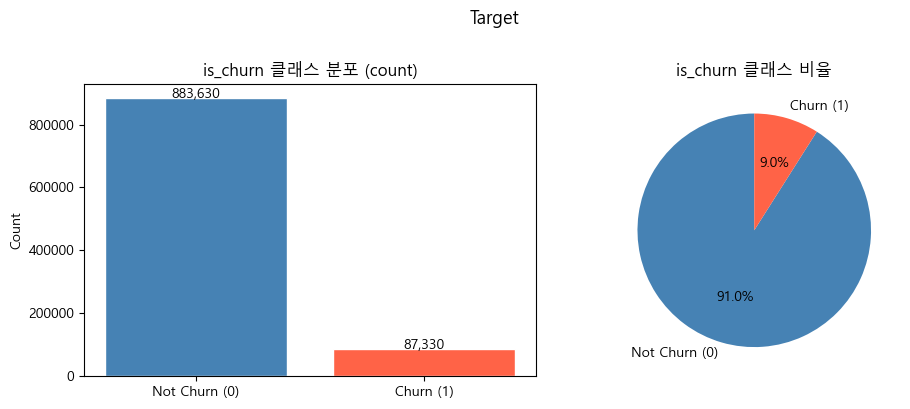

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4)) # 1행 2열의 서브플롯 생성

counts = train['is_churn'].value_counts()
axes[0].bar(['Not Churn (0)', 'Churn (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('is_churn 클래스 분포 (count)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=10)

ratios = train['is_churn'].value_counts(normalize=True) * 100
axes[1].pie(ratios.values,
            labels=['Not Churn (0)', 'Churn (1)'],
            autopct='%1.1f%%',
            colors=['steelblue', 'tomato'],
            startangle=90)
axes[1].set_title('is_churn 클래스 비율')

plt.suptitle('Target', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### train

In [21]:
members.head(10)
# city: 회원이 거주하는 도시 (1, 2, 3)
# bd: 회원의 나이 (0~100, -7000까지 이상치 존재)
# gender: 회원의 성별 (F, M, O) # NaN 값 존재
# registered_via: 회원이 가입한 방법 (1~9, 0은 이상치)
# registration_init_time: 회원이 가입한 날짜 (YYYYMMDD)

,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915
5,yLkV2gbZ4GLFwqTOXLVHz0VGrMYcgBGgKZ3kj9RiYu8=,4,30,male,9,20110916
6,jNCGK78YkTyId3H3wFavcBLDmz7pfqlvCfUKf4G1Lw4=,1,0,NaN,7,20110916
7,WH5Jq4mgtfUFXh2yz+HrcTXKS4Oess4k4W3qKolAeb0=,5,34,male,9,20110916
8,tKmbR4X5VXjHmxERrckawEMZ4znVy1lAQIR1vV5rdNk=,5,19,male,9,20110917
9,I0yFvqMoNkM8ZNHb617e1RBzIS/YRKemHO7Wj13EtA0=,13,63,male,9,20110918


In [22]:
members.info()

<class 'pandas.DataFrame'>
RangeIndex: 6769473 entries, 0 to 6769472
Data columns (total 6 columns):
 #   Column                  Dtype
---  ------                  -----
 0   msno                    str  
 1   city                    int64
 2   bd                      int64
 3   gender                  str  
 4   registered_via          int64
 5   registration_init_time  int64
dtypes: int64(4), str(2)
memory usage: 605.9 MB


In [23]:
# 결측치 확인
missing = members.isnull().sum()
missing_pct = members.isnull().mean() * 100
missing_df = pd.DataFrame({'결측치수': missing, '결측비율(%)': missing_pct})
print('=== members 결측치 ===')
display(missing_df[missing_df['결측치수'] > 0]) 

=== members 결측치 ===


,결측치수,결측비율(%)
gender,4429505,65.433528


In [26]:
# bd(나이 대용값) 이상치 확인 — 논문 4.1: 음수 ~ 1000 초과 이상치 존재
print('bd 통계:')
print(members['bd'].describe())
print()
n_outlier = ((members['bd'] <= 0) | (members['bd'] > 100)).sum()
print(f'bd 이상치 (0 이하 or 100 초과): {n_outlier:,}건 ({n_outlier/len(members):.1%})')

bd 통계:
count    6.769473e+06
mean     9.795794e+00
std      1.792590e+01
min     -7.168000e+03
25%      0.000000e+00
50%      0.000000e+00
75%      2.100000e+01
max      2.016000e+03
Name: bd, dtype: float64

bd 이상치 (0 이하 or 100 초과): 4,545,866건 (67.2%)


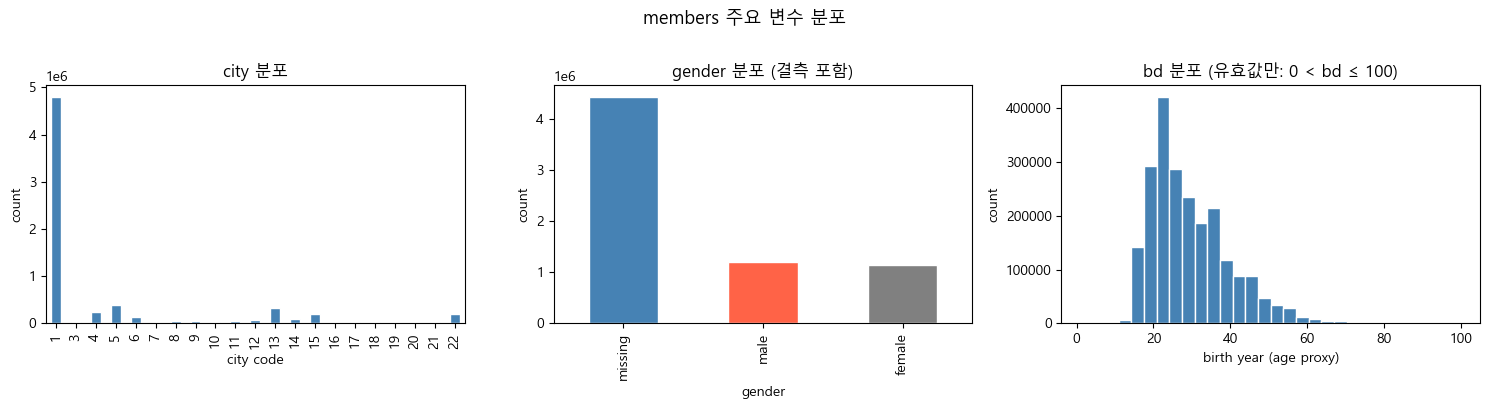

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

members['city'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('city 분포')
axes[0].set_xlabel('city code')
axes[0].set_ylabel('count')

members['gender'].fillna('missing').value_counts().plot(
    kind='bar', ax=axes[1],
    color=['steelblue', 'tomato', 'gray'], edgecolor='white')
axes[1].set_title('gender 분포 (결측 포함)')
axes[1].set_ylabel('count')

bd_valid = members['bd'][(members['bd'] > 0) & (members['bd'] <= 100)]
axes[2].hist(bd_valid, bins=30, color='steelblue', edgecolor='white')
axes[2].set_title('bd 분포 (유효값만: 0 < bd ≤ 100)')
axes[2].set_xlabel('birth year (age proxy)')
axes[2].set_ylabel('count')

plt.suptitle('members 주요 변수 분포', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### transcation


In [48]:
transactions.head(10)
# msno: 사용자 ID 당 다수의 거래 기록 존재

# payment_method_id: 결제 수단 (1~4, 0은 이상치)
# payment_plan_days: 결제 플랜 기간 (0은 이상치)
# plan_list_price: 결제 플랜 가격 (0은 이상치) 신대만 달러(NTD) 기준
# actual_amount_paid: 실제 결제 금액 (0은 이상치) 신대만 달러(NTD) 기준
# is_auto_renew: 자동 갱신 여부 (0, 1)
# transaction_date: 결제 날짜 (YYYYMMDD)
# membership_expire_date: 멤버십 만료 날짜 (YYYYMMDD)
# is_cancel: 사용자가 이 거래에서 멤버십을 취소했는지 여

,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,YyO+tlZtAXYXoZhNr3Vg3+dfVQvrBVGO8j1mfqe4ZHc=,41,30,129,129,1,20150930,20151101,0
1,AZtu6Wl0gPojrEQYB8Q3vBSmE2wnZ3hi1FbK1rQQ0A4=,41,30,149,149,1,20150930,20151031,0
2,UkDFI97Qb6+s2LWcijVVv4rMAsORbVDT2wNXF0aVbns=,41,30,129,129,1,20150930,20160427,0
3,M1C56ijxozNaGD0t2h68PnH2xtx5iO5iR2MVYQB6nBI=,39,30,149,149,1,20150930,20151128,0
4,yvj6zyBUaqdbUQSrKsrZ+xNDVM62knauSZJzakS9OW4=,39,30,149,149,1,20150930,20151121,0
5,KN7I82kjY0Tn76Ny95ncqBUVbO7b8AXrOPqZutKpxIM=,21,30,149,149,1,20150930,20151107,0
6,m5ptKif9BjdUghHXXomSezy5ohJiHm85PE13f/3kQaw=,39,30,149,149,1,20150930,20151128,0
7,uQxbyACsPOEkTIrv9jZgoGXelGBW81ZsSZKy9fhj5Z8=,39,30,149,149,1,20150930,20151125,0
8,LUPRfoE2r3WwVWhYO/TqQhjrL/qP6CO+/ORUlr7yNc0=,39,30,149,149,1,20150930,20151222,0
9,pMVjPLgVknaJYm9L0xUwxA2jmhpK7gfhGnsmmwX1mrE=,39,30,149,149,1,20150930,20151118,0


In [49]:
print(transactions.shape)
print("---------------------")
print(transactions.info())

(22978755, 9)
---------------------
<class 'pandas.DataFrame'>
RangeIndex: 22978755 entries, 0 to 22978754
Data columns (total 9 columns):
 #   Column                  Dtype
---  ------                  -----
 0   msno                    str  
 1   payment_method_id       int64
 2   payment_plan_days       int64
 3   plan_list_price         int64
 4   actual_amount_paid      int64
 5   is_auto_renew           int64
 6   transaction_date        int64
 7   membership_expire_date  int64
 8   is_cancel               int64
dtypes: int64(8), str(1)
memory usage: 2.5 GB
None


In [ ]:
# 결측치 확인
print(transactions.isnull().sum().sum())  

0


In [37]:
# 유저 당 거래횟수
txn_per_user = transactions.groupby('msno').size()
txn_per_user

msno
+++FOrTS7ab3tIgIh8eWwX4FqRv8w/FoiOuyXsFvphY=     1
+++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=     2
+++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=     5
+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=    21
+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=    27
                                                ..
zzz9+ZF4+GMyt63oU8xfjo1EkvRqH5OINlES0RUJI6I=    14
zzzF1KsGfHH3qI6qiSNSXC35UXmVKMVFdxkp7xmDMc0=     2
zzzN9thH22os1dRS0VHReY/8FTfGHOi86//d+wGGFsQ=    12
zzztsqkufVj9DPVJDM3FxDkhlbCL5z4aiYxgPSGkIK4=     1
zzzyOgMk9MljCerbCCYrVtvu85aSCiy7yCMjAEgNYMs=     1
Length: 2426143, dtype: int64

In [38]:
print(f"최대: {txn_per_user.max()}")
print(f"최소: {txn_per_user.min()}")

최대: 244
최소: 1


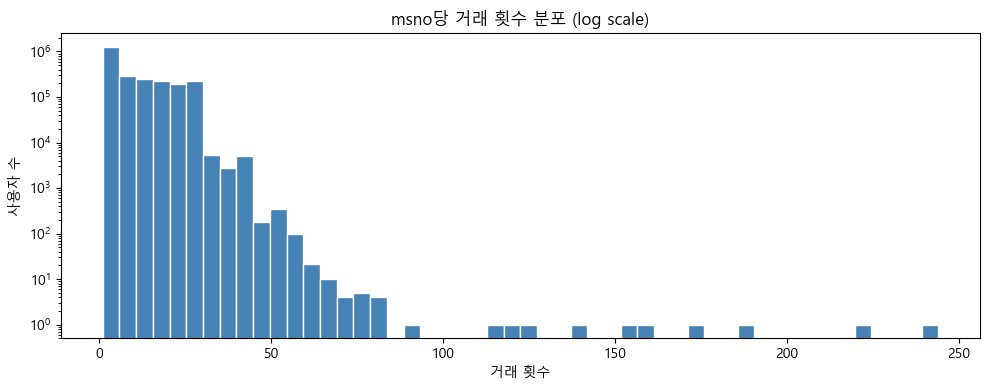

In [43]:
# 상위 5% 이상치 클립하여 거래 횟수 분포 시각화
plt.figure(figsize=(10, 4))
plt.hist(txn_per_user, bins=50, color='steelblue', edgecolor='white')
plt.yscale('log')
plt.title('msno당 거래 횟수 분포 (log scale)')
plt.xlabel('거래 횟수')
plt.ylabel('사용자 수')
plt.tight_layout()
plt.show()

할인 발생 건수: 867,020건 (3.8%)
payment_plan_days == 0: 872,342건
plan_list_price == 0: 1,516,957건


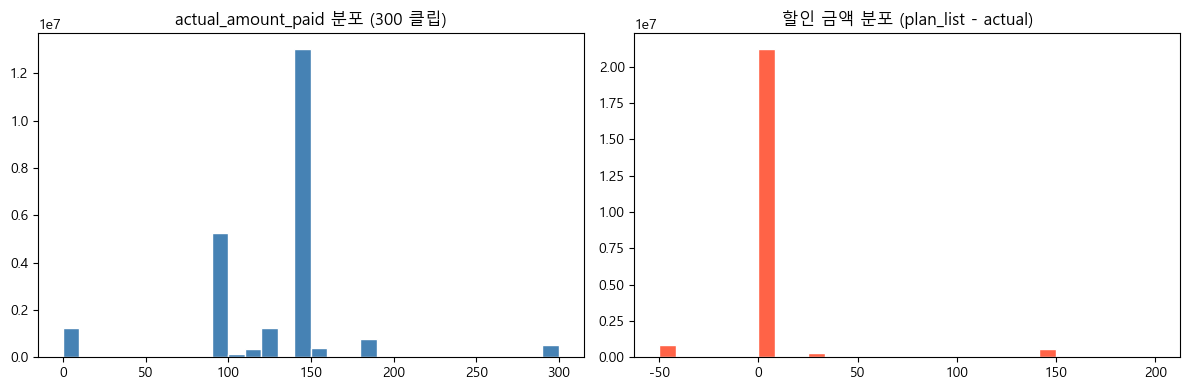

In [39]:
# 거래 이상치
price_diff = transactions['plan_list_price'] - transactions['actual_amount_paid']
print(f"할인 발생 건수: {(price_diff > 0).sum():,}건 ({(price_diff > 0).mean():.1%})")
print(f"payment_plan_days == 0: {(transactions['payment_plan_days'] == 0).sum():,}건")
print(f"plan_list_price == 0: {(transactions['plan_list_price'] == 0).sum():,}건")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(transactions['actual_amount_paid'].clip(upper=300), bins=30,
             color='steelblue', edgecolor='white')
axes[0].set_title('actual_amount_paid 분포 (300 클립)')
axes[1].hist(price_diff.clip(lower=-50, upper=200), bins=30,
             color='tomato', edgecolor='white')
axes[1].set_title('할인 금액 분포 (plan_list - actual)')
plt.tight_layout()
plt.show()


=== 결제 수단 / 플랜 분포 ===


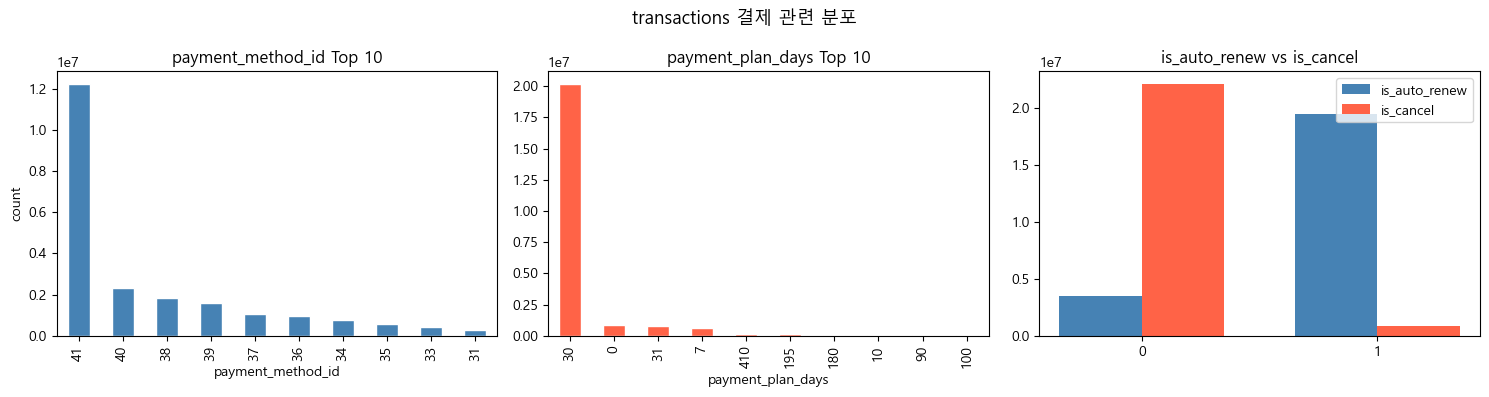

In [44]:
########## EDA 4. 결제 수단 / 플랜 분포 ##########
print("\n=== 결제 수단 / 플랜 분포 ===")
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

transactions['payment_method_id'].value_counts().head(10).plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('payment_method_id Top 10')
axes[0].set_ylabel('count')

transactions['payment_plan_days'].value_counts().head(10).plot(
    kind='bar', ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('payment_plan_days Top 10')

x = np.arange(2)
w = 0.35
ar = transactions['is_auto_renew'].value_counts().sort_index()
ic = transactions['is_cancel'].value_counts().sort_index()
axes[2].bar(x - w/2, ar.values, w, label='is_auto_renew', color='steelblue')
axes[2].bar(x + w/2, ic.values, w, label='is_cancel', color='tomato')
axes[2].set_xticks(x); axes[2].set_xticklabels(['0', '1'])
axes[2].set_title('is_auto_renew vs is_cancel')
axes[2].legend()

plt.suptitle('transactions 결제 관련 분포', fontsize=13)
plt.tight_layout()
plt.show()

In [52]:
# membership_expire_date 9999년 등 이상치
expire_raw = transactions['membership_expire_date'].astype(str)
print(f"membership_expire_date 9999년 이상: {(expire_raw.str[:4].astype(int) > 2030).sum():,}건")
print(f"transaction_date 범위: {transactions['transaction_date'].min()} ~ {transactions['transaction_date'].max()}")
print(f"membership_expire_date 범위: {transactions['membership_expire_date'].min()} ~ {transactions['membership_expire_date'].max()}")

membership_expire_date 9999년 이상: 6건
transaction_date 범위: 20150101 ~ 20170331
membership_expire_date 범위: 19700101 ~ 20361015


### user_logs

In [53]:
user_logs.head(10)

,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,u9E91QDTvHLq6NXjEaWv8u4QIqhrHk72kE+w31Gnhdg=,20170331,8,4,0,1,21,18,6309.273
1,nTeWW/eOZA/UHKdD5L7DEqKKFTjaAj3ALLPoAWsU8n0=,20170330,2,2,1,0,9,11,2390.699
2,2UqkWXwZbIjs03dHLU9KHJNNEvEkZVzm69f3jCS+uLI=,20170331,52,3,5,3,84,110,23203.337
3,ycwLc+m2O0a85jSLALtr941AaZt9ai8Qwlg9n0Nql5U=,20170331,176,4,2,2,19,191,7100.454
4,EGcbTofOSOkMmQyN1NMLxHEXJ1yV3t/JdhGwQ9wXjnI=,20170331,2,1,0,1,112,93,28401.558
5,qR/ndQ5B+1cY+c9ihwLoiz+RFiqEnGyQKo32ZErEVKo=,20170331,3,0,0,0,39,41,9786.842
6,N6ch5ArfJixq9mvARJv9ip1D11uvDVazz6Qup5mX7DI=,20170330,9,1,0,0,18,26,4920.255
7,JEjl2W1ivEI6epeobW3n5rDg/r6PJm4OJhtmhwYaQIc=,20170331,181,68,5,3,54,291,22433.105
8,lPK4IYIFdfTT6pq7x2dSV1Vy9j9hNMWzf7XfYBUBz5E=,20170331,3,0,1,1,181,150,46240.281
9,cDgnvwQwCwru2m3zcSuK5oTr6pr1nMPQ/6RerOmxrs0=,20170331,5,4,1,1,30,31,7881.618


In [54]:
user_logs.info()

<class 'pandas.DataFrame'>
RangeIndex: 18396362 entries, 0 to 18396361
Data columns (total 9 columns):
 #   Column      Dtype  
---  ------      -----  
 0   msno        str    
 1   date        int64  
 2   num_25      int64  
 3   num_50      int64  
 4   num_75      int64  
 5   num_985     int64  
 6   num_100     int64  
 7   num_unq     int64  
 8   total_secs  float64
dtypes: float64(1), int64(7), str(1)
memory usage: 2.0 GB


In [56]:
# 결측치 확인
missing = user_logs.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "결측치 없음")

결측치 없음


In [59]:
# user_logs msno당 로그 수 분포
logs_per_user = user_logs.groupby('msno').size()
logs_per_user

msno
+++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=    26
+++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=    31
+++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=    28
+++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=    21
++/9R3sX37CjxbY/AaGvbwr3QkwElKBCtSvVzhCBDOk=    29
                                                ..
zzy7iqSpfcRq7R4hmKKuhI+CJRs79a6pteqEggpiNO0=    31
zzyHq6TK2+cBkeGFUHvh12Z7UxFZiSM7dOOSllSBPDw=    16
zzz1Dc3P9s53HAowRTrm3fNsWju5yeN4YBfNDq7Z99Q=    20
zzzF1KsGfHH3qI6qiSNSXC35UXmVKMVFdxkp7xmDMc0=    11
zzzueVTwIa5TjXnG2c77bohCVkuksqLkd5mQTP0wTwQ=     1
Length: 1103894, dtype: int64

[1] 파일 로드 중...
[1] 로드 완료 — 18,396,362 rows | 37.3s
[2] msno 기준 집계 중...
[2] 집계 완료 — 유저 수: 1,103,894 | 23.8s
(1103894, 10)


,msno,total_secs,num_25,num_50,num_75,num_985,num_100,num_unq,log_count,last_listen_date
0,u9E91QDTvHLq6NXjEaWv8u4QIqhrHk72kE+w31Gnhdg=,348628.540,407,100,87,119,1151,1176,31,20170331
1,nTeWW/eOZA/UHKdD5L7DEqKKFTjaAj3ALLPoAWsU8n0=,72117.966,82,58,10,7,261,338,20,20170330
2,2UqkWXwZbIjs03dHLU9KHJNNEvEkZVzm69f3jCS+uLI=,270728.515,508,55,35,39,959,1255,31,20170331



=== log_count 분포 ===
count    1.103894e+06
mean     1.666497e+01
std      1.030333e+01
min      1.000000e+00
25%      7.000000e+00
50%      1.800000e+01
75%      2.600000e+01
max      3.100000e+01
Name: log_count, dtype: float64


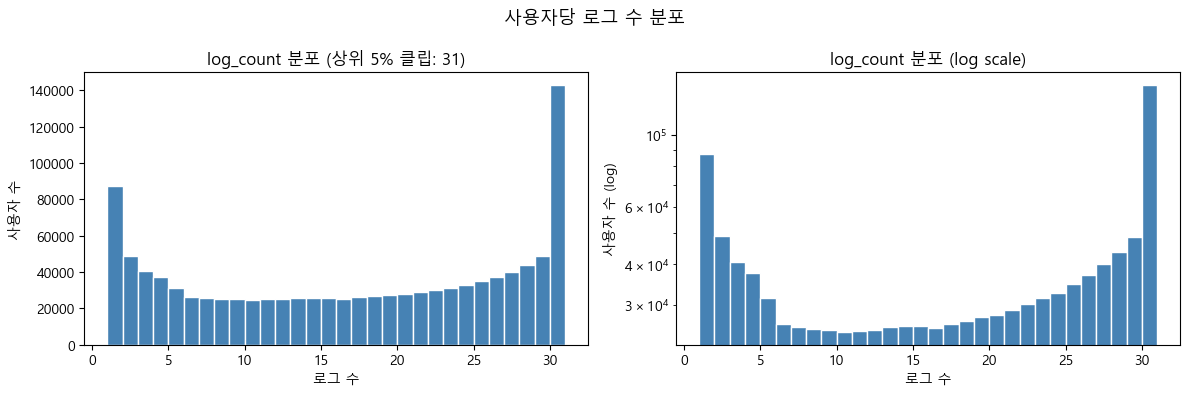

In [61]:
import pandas as pd
import time

bt0 = time.time()

df = pd.read_csv("data/raw/user_logs_v2.csv")
print(f"[1] 로드 완료 — {len(df):,} rows | {time.time()-t0:.1f}s")

print("[2] msno 기준 집계 중...")
t1 = time.time()

agg_df = df.groupby("msno", sort=False).agg(
    total_secs       = ("total_secs", "sum"),
    num_25           = ("num_25",     "sum"),
    num_50           = ("num_50",     "sum"),
    num_75           = ("num_75",     "sum"),
    num_985          = ("num_985",    "sum"),
    num_100          = ("num_100",    "sum"),
    num_unq          = ("num_unq",    "sum"),
    log_count        = ("date",       "count"),
    last_listen_date = ("date",       "max"),
).reset_index()

print(f"[2] 집계 완료 — 유저 수: {len(agg_df):,} | {time.time()-t1:.1f}s")
print(agg_df.shape)
display(agg_df.head(3))


print("\n=== log_count 분포 ===")
print(agg_df["log_count"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(agg_df["log_count"].clip(upper=agg_df["log_count"].quantile(0.95)),
             bins=30, color="steelblue", edgecolor="white")
axes[0].set_title(f"log_count 분포 (상위 5% 클립: {agg_df['log_count'].quantile(0.95):.0f})")
axes[0].set_xlabel("로그 수")
axes[0].set_ylabel("사용자 수")

axes[1].hist(agg_df["log_count"], bins=30, color="steelblue", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("log_count 분포 (log scale)")
axes[1].set_xlabel("로그 수")
axes[1].set_ylabel("사용자 수 (log)")

plt.suptitle("사용자당 로그 수 분포", fontsize=13)
plt.tight_layout()
plt.show()

In [64]:
print(f"로그 max: {agg_df['log_count'].max()}")
print(f"로그 min: {agg_df['log_count'].min()}")

로그 max: 31
로그 min: 1


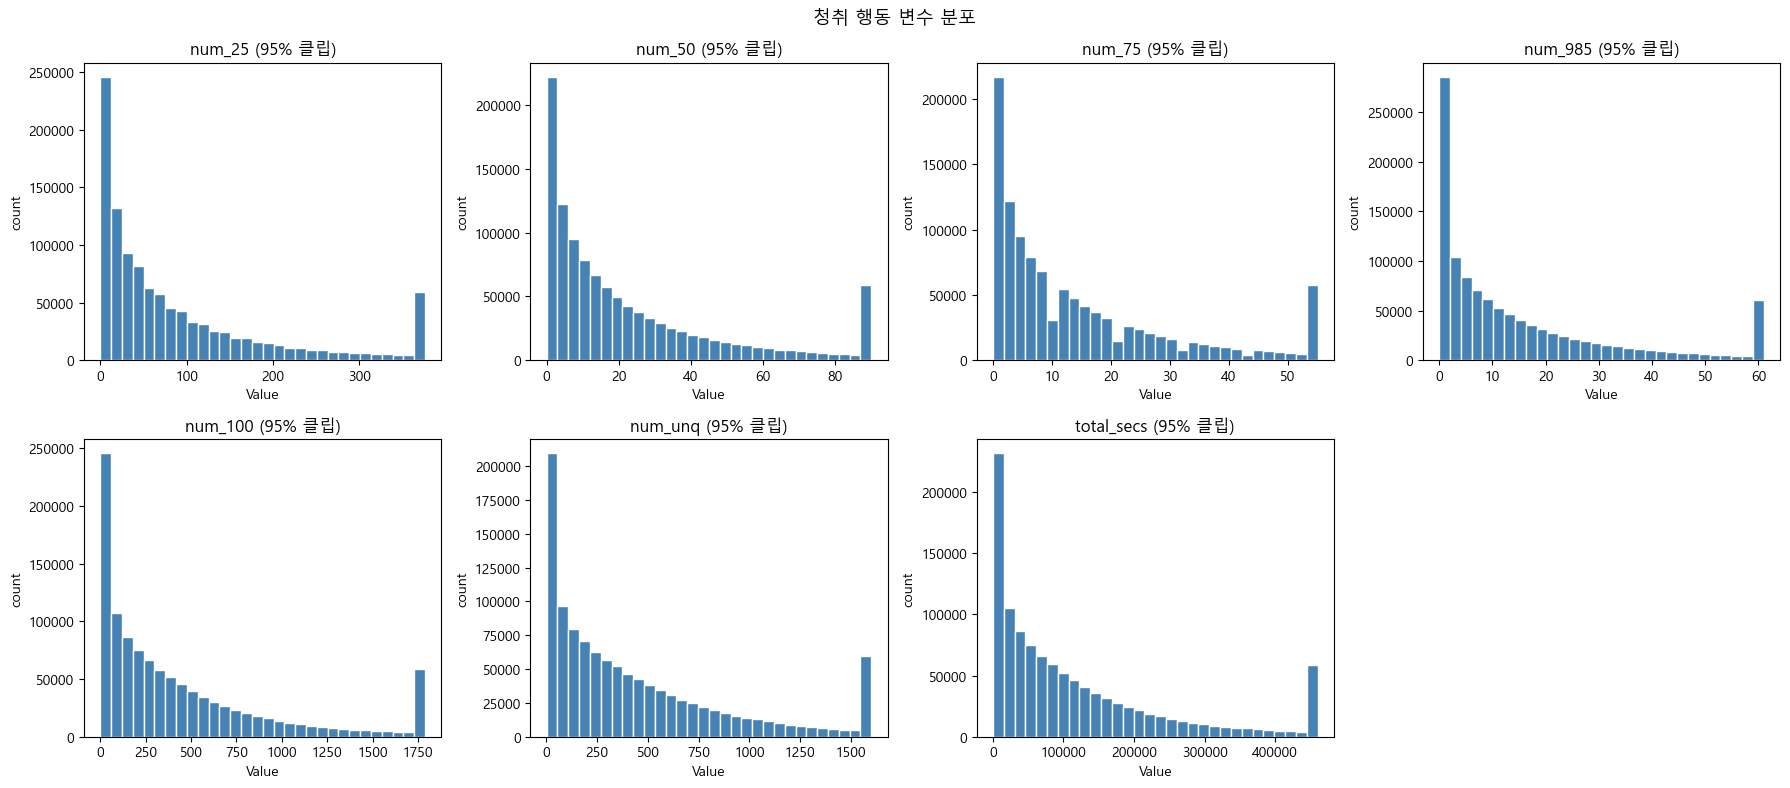

In [65]:
# 청취 행동 변수 분포
listen_cols = ["num_25", "num_50", "num_75", "num_985", "num_100", "num_unq", "total_secs"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(listen_cols):
    clip_val = agg_df[col].quantile(0.95)
    axes[i].hist(agg_df[col].clip(upper=clip_val), bins=30,
                 color="steelblue", edgecolor="white")
    axes[i].set_title(f"{col} (95% 클립)")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("count")

fig.delaxes(axes[-1])
plt.suptitle("청취 행동 변수 분포", fontsize=13)
plt.tight_layout()
plt.show()